In [5]:
import requests
import pandas as pd
import io

url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
headers = {"Accept": "application/vnd.sdmx.data+csv;version=1.0.0"}
params = {"startPeriod": "2015", "endPeriod": "2023"}

print("⏳ Scaricando dati 2015-2023, può volerci qualche minuto...")
response = requests.get(url, headers=headers, params=params, timeout=180)
print("Status:", response.status_code)

if response.status_code == 200:
    df = pd.read_csv(io.StringIO(response.text))
    print("✅ Dati scaricati!")
    print("Dimensioni:", df.shape)
    print("Anni disponibili:", sorted(df['TIME_PERIOD'].unique()))

⏳ Scaricando dati 2015-2023, può volerci qualche minuto...
Status: 200
✅ Dati scaricati!
Dimensioni: (233538, 16)
Anni disponibili: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [6]:
# Separiamo i due tipi di dati
df_incidenti = df[df['DATA_TYPE'] == 'ROADACC'].copy()
df_vittime = df[df['DATA_TYPE'] == 'KILLINJ'].copy()

print("Incidenti stradali:", df_incidenti.shape)
print("Morti e feriti:", df_vittime.shape)

# Valori totali (RESULT == '9')
df_totali = df[df['RESULT'] == '9'].copy()
print("\nRighe con totali:", df_totali.shape)

# Statistiche base
print("\nIncidenti per anno (totali):")
print(df_incidenti[df_incidenti['RESULT']=='9'].groupby('TIME_PERIOD')['OBS_VALUE'].sum())

Incidenti stradali: (77846, 16)
Morti e feriti: (155692, 16)

Righe con totali: (77846, 16)

Incidenti per anno (totali):
TIME_PERIOD
2015    174539
2016    175791
2017    174933
2018    172553
2019    172183
2020    118298
2021    151875
2022    165889
2023    166525
2024    173364
Name: OBS_VALUE, dtype: int64


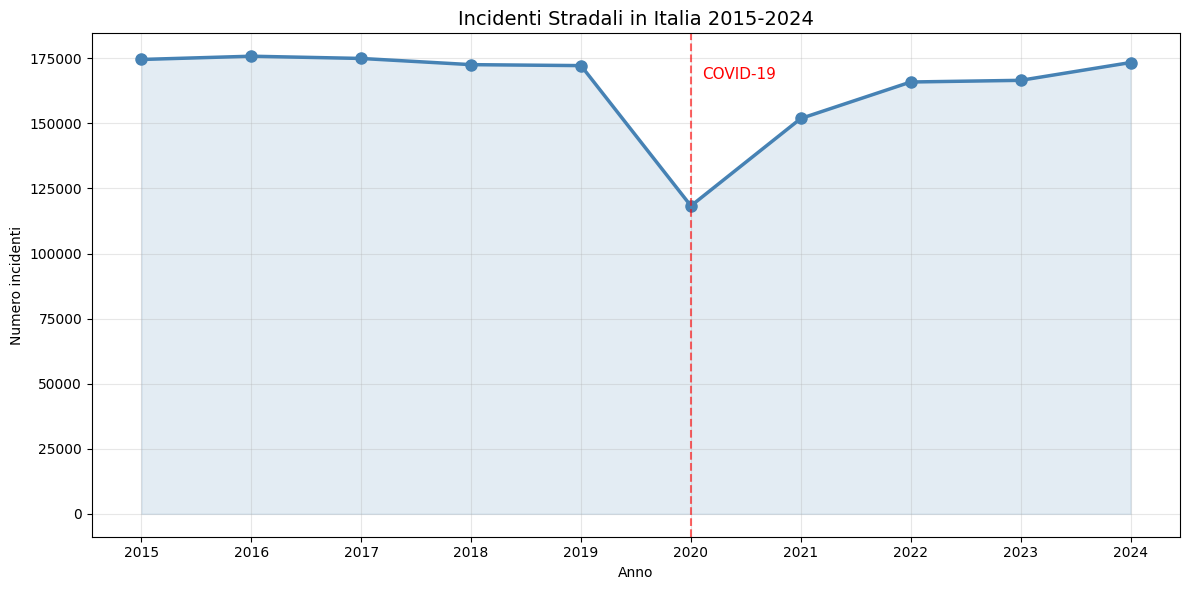

In [7]:
# Grafico incidenti per anno
import matplotlib.pyplot as plt

dati_anno = df_incidenti[df_incidenti['RESULT']=='9'].groupby(
    'TIME_PERIOD')['OBS_VALUE'].sum()

plt.figure(figsize=(12, 6))
plt.plot(dati_anno.index, dati_anno.values,
         'o-', color='steelblue', linewidth=2.5, markersize=8)
plt.fill_between(dati_anno.index, dati_anno.values,
                 alpha=0.15, color='steelblue')

# Evidenzia il 2020
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.6)
plt.text(2020.1, dati_anno.max()*0.95, 'COVID-19',
         color='red', fontsize=11)

plt.title('Incidenti Stradali in Italia 2015-2024', fontsize=14)
plt.xlabel('Anno')
plt.ylabel('Numero incidenti')
plt.xticks(dati_anno.index)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Controlliamo df_vittime
print("Shape df_vittime:", df_vittime.shape)
print("\nRESULT valori unici:", df_vittime['RESULT'].unique())
print("\nDATA_TYPE valori unici:", df_vittime['DATA_TYPE'].unique())
print("\nPrime 5 righe:")
print(df_vittime[['DATA_TYPE', 'RESULT', 'TIME_PERIOD', 'OBS_VALUE']].head(10))

Shape df_vittime: (155692, 16)

RESULT valori unici: ['F' 'M']

DATA_TYPE valori unici: ['KILLINJ']

Prime 5 righe:
  DATA_TYPE RESULT  TIME_PERIOD  OBS_VALUE
0   KILLINJ      F         2015          9
1   KILLINJ      F         2016          8
2   KILLINJ      F         2017          0
3   KILLINJ      F         2018          1
4   KILLINJ      F         2019          5
5   KILLINJ      F         2020          4
6   KILLINJ      F         2021          2
7   KILLINJ      F         2022          5
8   KILLINJ      F         2023          6
9   KILLINJ      F         2024          5


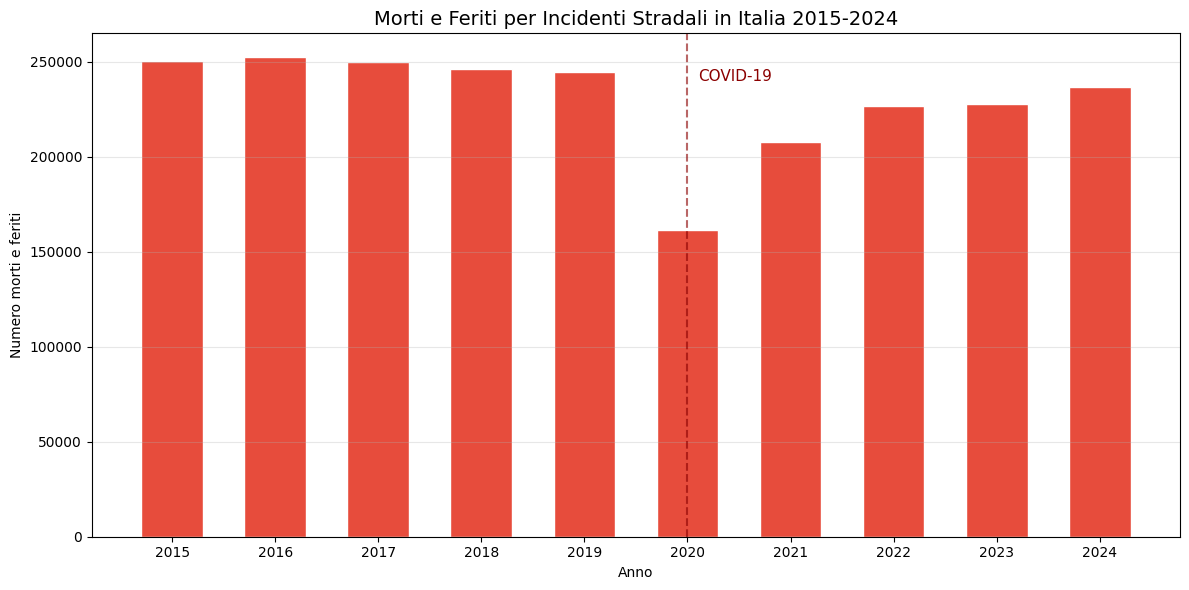


Morti e feriti per anno:
TIME_PERIOD
2015    250348
2016    252458
2017    250128
2018    246253
2019    244557
2020    161643
2021    207603
2022    226634
2023    227673
2024    236883
Name: OBS_VALUE, dtype: int64


In [10]:
# Sommiamo F + M per ottenere il totale vittime per anno
vittime_anno = df_vittime.groupby('TIME_PERIOD')['OBS_VALUE'].sum()

plt.figure(figsize=(12, 6))
plt.bar(vittime_anno.index, vittime_anno.values,
        color='#e74c3c', edgecolor='white', width=0.6)
plt.axvline(x=2020, color='darkred', linestyle='--', alpha=0.6)
plt.text(2020.1, vittime_anno.max()*0.95, 'COVID-19',
         color='darkred', fontsize=11)
plt.title('Morti e Feriti per Incidenti Stradali in Italia 2015-2024',
          fontsize=14)
plt.xlabel('Anno')
plt.ylabel('Numero morti e feriti')
plt.xticks(vittime_anno.index)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nMorti e feriti per anno:")
print(vittime_anno)

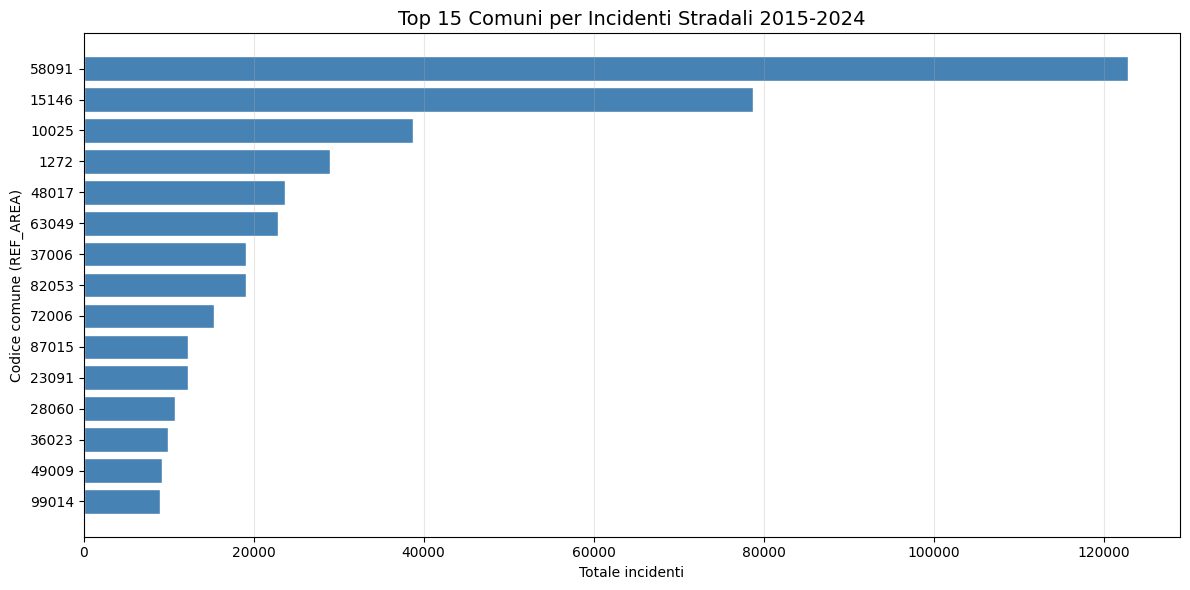


Top 15 comuni (codice ISTAT):
REF_AREA
58091    122801
15146     78668
10025     38779
1272      28929
48017     23708
63049     22886
37006     19163
82053     19087
72006     15346
87015     12322
23091     12242
28060     10712
36023      9905
49009      9241
99014      8993
Name: OBS_VALUE, dtype: int64


In [11]:
# Top 15 comuni per numero di incidenti totali
top_comuni = df_incidenti[df_incidenti['RESULT']=='9'].groupby(
    'REF_AREA')['OBS_VALUE'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.barh(top_comuni.index.astype(str), top_comuni.values,
         color='steelblue', edgecolor='white')
plt.title('Top 15 Comuni per Incidenti Stradali 2015-2024', fontsize=14)
plt.xlabel('Totale incidenti')
plt.ylabel('Codice comune (REF_AREA)')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 15 comuni (codice ISTAT):")
print(top_comuni)

In [12]:
# Codici ISTAT noti delle grandi città italiane
# per verificare se i top comuni corrispondono
codici_noti = {
    58091: 'Roma',
    15146: 'Milano',
    10025: 'Torino',
    1272:  'Genova',
    48017: 'Bologna',
    63049: 'Napoli',
    37006: 'Verona',
    82053: 'Bari',
    72006: 'Taranto',
    87015: 'Cosenza',
    23091: 'Brescia',
    28060: 'Padova',
    36023: 'Vicenza',
    49009: 'Firenze',
    99014: 'Palermo'
}

print("Top 15 comuni con nomi:")
for codice, incidenti in top_comuni.items():
    nome = codici_noti.get(codice, f'Comune {codice}')
    print(f"  {nome:15} ({codice}): {incidenti:,} incidenti")

Top 15 comuni con nomi:
  Roma            (58091): 122,801 incidenti
  Milano          (15146): 78,668 incidenti
  Torino          (10025): 38,779 incidenti
  Genova          (1272): 28,929 incidenti
  Bologna         (48017): 23,708 incidenti
  Napoli          (63049): 22,886 incidenti
  Verona          (37006): 19,163 incidenti
  Bari            (82053): 19,087 incidenti
  Taranto         (72006): 15,346 incidenti
  Cosenza         (87015): 12,322 incidenti
  Brescia         (23091): 12,242 incidenti
  Padova          (28060): 10,712 incidenti
  Vicenza         (36023): 9,905 incidenti
  Firenze         (49009): 9,241 incidenti
  Palermo         (99014): 8,993 incidenti


In [13]:
# Aggiungiamo i nomi dei comuni al dataset principale
df_incidenti['Nome_Comune'] = df_incidenti['REF_AREA'].map(codici_noti)

# Dataset pulito solo con comuni identificati
df_pulito = df_incidenti[
    (df_incidenti['RESULT'] == '9') &
    (df_incidenti['Nome_Comune'].notna())
].copy()

print("Dataset pulito:")
print(df_pulito[['REF_AREA', 'Nome_Comune', 'TIME_PERIOD', 'OBS_VALUE']].head(15))
print(f"\nComuni identificati: {df_pulito['Nome_Comune'].nunique()}")
print(f"Anni: {sorted(df_pulito['TIME_PERIOD'].unique())}")

Dataset pulito:
       REF_AREA Nome_Comune  TIME_PERIOD  OBS_VALUE
7877       1272      Genova         2015       3163
7878       1272      Genova         2016       3013
7879       1272      Genova         2017       3081
7880       1272      Genova         2018       2997
7881       1272      Genova         2019       2973
7882       1272      Genova         2020       2088
7883       1272      Genova         2021       2793
7884       1272      Genova         2022       2935
7885       1272      Genova         2023       2918
7886       1272      Genova         2024       2968
36905     10025      Torino         2015       4345
36906     10025      Torino         2016       4205
36907     10025      Torino         2017       4279
36908     10025      Torino         2018       4154
36909     10025      Torino         2019       3921

Comuni identificati: 15
Anni: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64

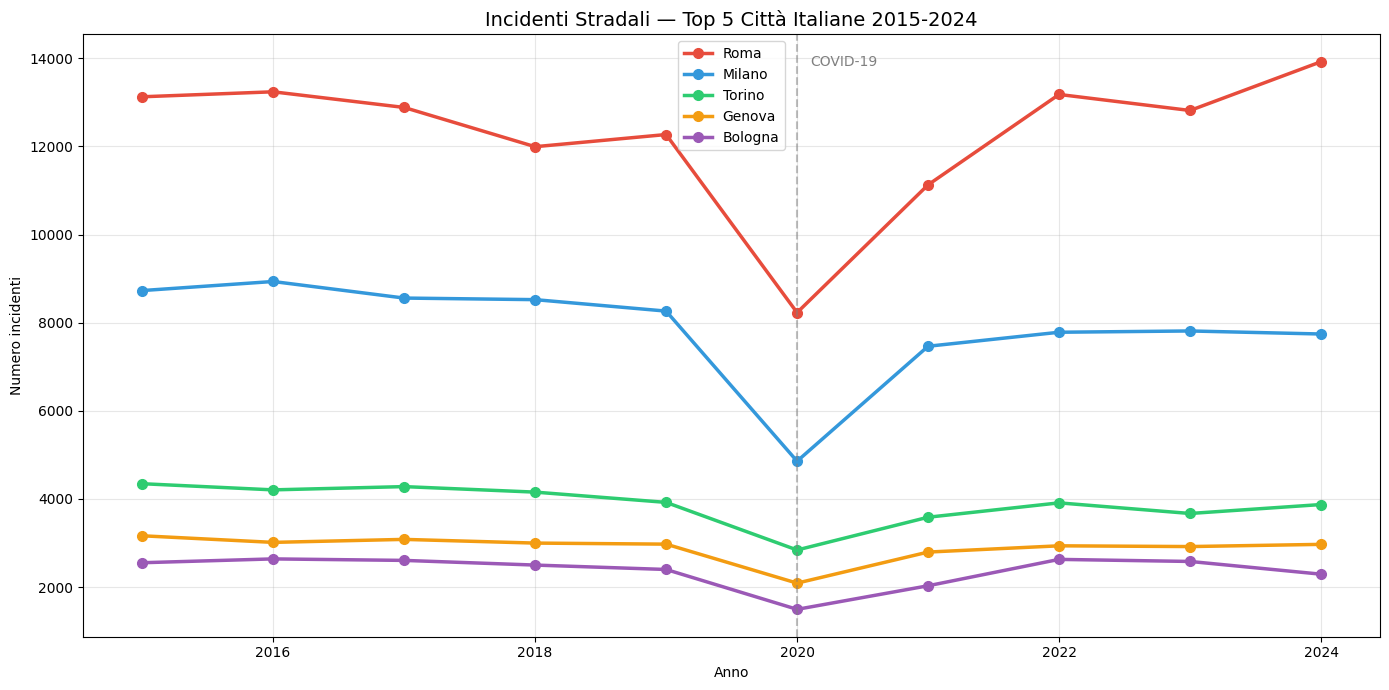

In [14]:
# Incidenti per città nel tempo
fig, ax = plt.subplots(figsize=(14, 7))

top5 = ['Roma', 'Milano', 'Torino', 'Genova', 'Bologna']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for citta, color in zip(top5, colors):
    dati = df_pulito[df_pulito['Nome_Comune'] == citta].sort_values('TIME_PERIOD')
    ax.plot(dati['TIME_PERIOD'], dati['OBS_VALUE'],
            'o-', label=citta, color=color, linewidth=2.5, markersize=7)

ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5)
ax.text(2020.1, ax.get_ylim()[1]*0.95, 'COVID-19', color='gray', fontsize=10)
ax.set_title('Incidenti Stradali — Top 5 Città Italiane 2015-2024', fontsize=14)
ax.set_xlabel('Anno')
ax.set_ylabel('Numero incidenti')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

# Carica il CSV SITUAS (separatore punto e virgola)
df_situas = pd.read_csv('/content/Comuni - Dimensione Data Indagine.csv',
                         sep=';', encoding='utf-8-sig')

print("Dimensioni:", df_situas.shape)
print("\nColonne:", df_situas.columns.tolist())
print("\nPrime 3 righe:")
print(df_situas.head(3))

Dimensioni: (7903, 15)

Colonne: ['Codice Ripartizione geografica', 'Codice Regione', 'Codice Provincia (Storico)', 'Codice Provincia/Uts', 'Codice Comune (alfanumerico)', 'Codice Comune (numerico)', 'Comune', 'Comune (dizione straniera)', 'Sigla automobilistica', 'Popolazione legale', 'Anno Censimento', 'Superficie (Kmq)', 'Anno (Superficie)', 'Popolazione residente', 'Anno (Popolazione residente)']

Prime 3 righe:
   Codice Ripartizione geografica  Codice Regione  Codice Provincia (Storico)  \
0                               1               1                           1   
1                               1               1                           1   
2                               1               1                           1   

   Codice Provincia/Uts  Codice Comune (alfanumerico)  \
0                   201                          1001   
1                   201                          1002   
2                   201                          1003   

   Codice Comune (numerico

In [17]:
# Uniamo ISTAT con SITUAS tramite il codice comune
df_merged = df_incidenti[df_incidenti['RESULT']=='9'].merge(
    df_situas[['Codice Comune (numerico)', 'Comune', 'Popolazione residente']],
    left_on='REF_AREA',
    right_on='Codice Comune (numerico)',
    how='left'
)

print("Dataset unito:", df_merged.shape)
print("\nComuni con nome:", df_merged['Comune'].notna().sum())
print("\nPrime 5 righe:")
print(df_merged[['REF_AREA', 'Comune', 'TIME_PERIOD',
                  'OBS_VALUE', 'Popolazione residente']].head())

Dataset unito: (77846, 20)

Comuni con nome: 76904

Prime 5 righe:
   REF_AREA Comune  TIME_PERIOD  OBS_VALUE  Popolazione residente
0      1001  Agliè         2015          5                 2545.0
1      1001  Agliè         2016          5                 2545.0
2      1001  Agliè         2017          0                 2545.0
3      1001  Agliè         2018          1                 2545.0
4      1001  Agliè         2019          3                 2545.0


In [18]:
# Calcoliamo incidenti per 100.000 abitanti
df_merged['Incidenti_per_100k'] = (
    df_merged['OBS_VALUE'] / df_merged['Popolazione residente'] * 100000
).round(2)

# Rimuoviamo comuni senza popolazione o con popolazione = 0
df_merged = df_merged[df_merged['Popolazione residente'] > 0].copy()

# Top 15 comuni per incidenti per capita (media su tutti gli anni)
top_percapita = df_merged.groupby('Comune').agg(
    Totale_incidenti=('OBS_VALUE', 'sum'),
    Media_incidenti_100k=('Incidenti_per_100k', 'mean'),
    Popolazione=('Popolazione residente', 'first')
).sort_values('Media_incidenti_100k', ascending=False).head(15)

print("Top 15 comuni per incidenti per 100k abitanti:")
print(top_percapita[['Totale_incidenti', 'Media_incidenti_100k', 'Popolazione']])

Top 15 comuni per incidenti per 100k abitanti:
                         Totale_incidenti  Media_incidenti_100k  Popolazione
Comune                                                                      
Castel Condino                         39           1978.691111        219.0
Moncenisio                              7           1897.017778         41.0
Bard                                   19           1696.428000        112.0
Ponte Gardena/Waidbruck                31           1542.287000        201.0
Dorio                                  41           1414.772222        322.0
Brienno                                46           1373.134000        335.0
Carrodano                              65           1365.545000        476.0
Forte dei Marmi                       976           1352.364000       7217.0
Priero                                 70           1330.799000        526.0
Argentera                              10           1282.050000         78.0
Belforte Monferrato          

Top 15 città (>50k abitanti) per incidenti per 100k abitanti:
               Totale_incidenti  Media_incidenti_100k  Popolazione
Comune                                                            
Bergamo                    8858               738.210     119993.0
Genova                    38779               684.644     566410.0
Firenze                   23708               643.507     368419.0
Sanremo                    3384               633.103      53451.0
Pisa                       5589               621.214      89969.0
Rimini                     8993               598.576     150240.0
Livorno                    9241               594.775     155370.0
Savona                     3472               588.983      58949.0
Milano                    78668               572.305    1374582.0
Viareggio                  3418               558.033      61251.0
Massa                      3691               551.086      66977.0
Bolzano/Bozen              5883               547.423     107467.0


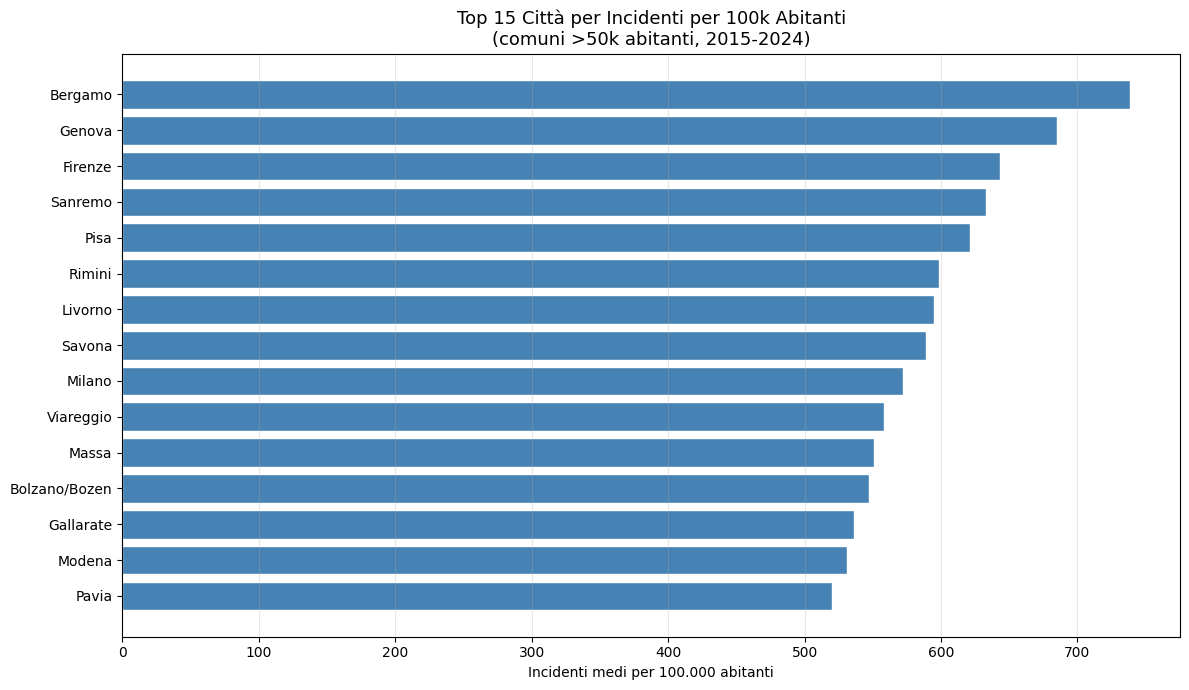

In [19]:
# Filtriamo comuni con almeno 50.000 abitanti (città significative)
df_grandi = df_merged[df_merged['Popolazione residente'] >= 50000].copy()

top_grandi = df_grandi.groupby('Comune').agg(
    Totale_incidenti=('OBS_VALUE', 'sum'),
    Media_incidenti_100k=('Incidenti_per_100k', 'mean'),
    Popolazione=('Popolazione residente', 'first')
).sort_values('Media_incidenti_100k', ascending=False).head(15)

print("Top 15 città (>50k abitanti) per incidenti per 100k abitanti:")
print(top_grandi[['Totale_incidenti', 'Media_incidenti_100k', 'Popolazione']])

# Grafico
plt.figure(figsize=(12, 7))
plt.barh(top_grandi.index, top_grandi['Media_incidenti_100k'],
         color='steelblue', edgecolor='white')
plt.title('Top 15 Città per Incidenti per 100k Abitanti\n(comuni >50k abitanti, 2015-2024)',
          fontsize=13)
plt.xlabel('Incidenti medi per 100.000 abitanti')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

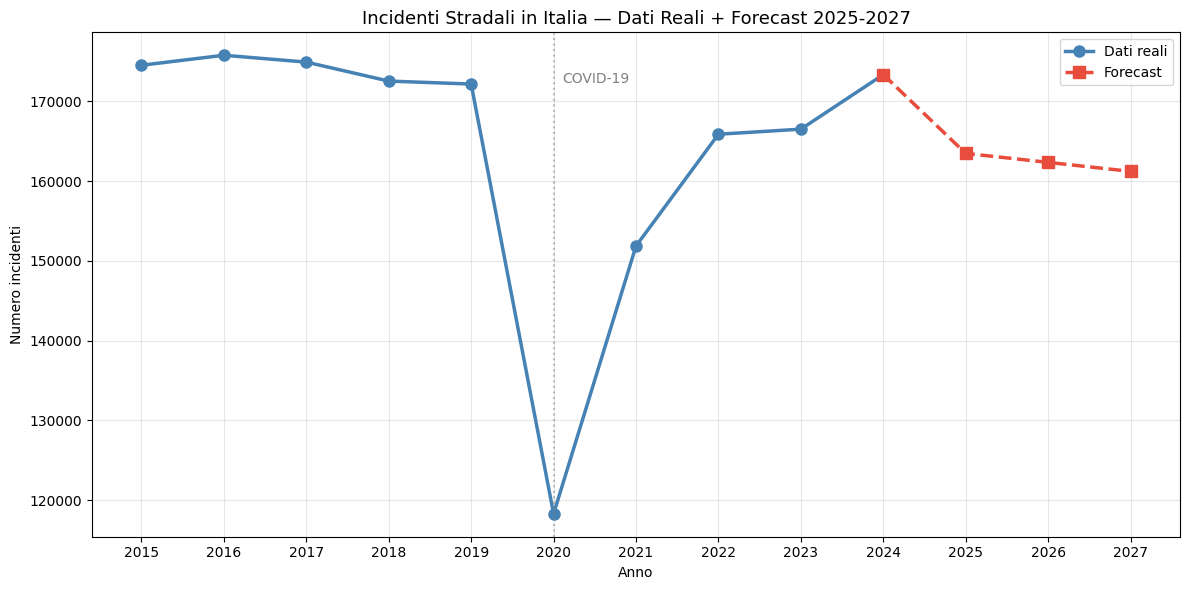


Previsioni:
  2025: ~163,484 incidenti stimati
  2026: ~162,358 incidenti stimati
  2027: ~161,232 incidenti stimati


In [20]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Forecast incidenti nazionali 2025-2027
# Escludiamo 2020 perché anomalo (COVID)
dati_nazionali = df_incidenti[df_incidenti['RESULT']=='9'].groupby(
    'TIME_PERIOD')['OBS_VALUE'].sum()

# Dati senza 2020
anni_train = dati_nazionali[dati_nazionali.index != 2020]
X = anni_train.index.values.reshape(-1, 1)
y = anni_train.values

model = LinearRegression()
model.fit(X, y)

# Forecast
anni_forecast = np.array([2025, 2026, 2027]).reshape(-1, 1)
previsioni = model.predict(anni_forecast)

# Grafico
plt.figure(figsize=(12, 6))
plt.plot(dati_nazionali.index, dati_nazionali.values,
         'o-', color='steelblue', linewidth=2.5, markersize=8,
         label='Dati reali')
plt.plot([2024, 2025, 2026, 2027],
         [dati_nazionali[2024]] + list(previsioni),
         's--', color='#e74c3c', linewidth=2.5, markersize=8,
         label='Forecast')
plt.axvline(x=2020, color='gray', linestyle=':', alpha=0.5)
plt.text(2020.1, dati_nazionali.max()*0.98, 'COVID-19',
         color='gray', fontsize=10)
plt.title('Incidenti Stradali in Italia — Dati Reali + Forecast 2025-2027',
          fontsize=13)
plt.xlabel('Anno')
plt.ylabel('Numero incidenti')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(list(range(2015, 2028)))
plt.tight_layout()
plt.show()

print("\nPrevisioni:")
for anno, prev in zip([2025, 2026, 2027], previsioni):
    print(f"  {anno}: ~{int(prev):,} incidenti stimati")

In [22]:
from scipy import stats

# Aggiungiamo area geografica dal codice regione SITUAS
df_merged2 = df_merged.merge(
    df_situas[['Codice Comune (numerico)', 'Codice Regione']],
    left_on='REF_AREA',
    right_on='Codice Comune (numerico)',
    how='left'
)

# Classifichiamo Nord/Centro/Sud
def area_geografica(codice_regione):
    if codice_regione in [1,2,3,4,5,6,7,8]:
        return 'Nord'
    elif codice_regione in [9,10,11,12]:
        return 'Centro'
    else:
        return 'Sud e Isole'

df_merged2['Area'] = df_merged2['Codice Regione'].apply(area_geografica)

# Incidenti per area
print("Incidenti totali per area geografica:")
print(df_merged2.groupby('Area')['OBS_VALUE'].sum())

# Chi-square test: distribuzione incidenti Nord vs Sud
# Confrontiamo 2019 (pre-COVID) vs 2021 (post-COVID)
pre_covid = df_merged2[df_merged2['TIME_PERIOD']==2019].groupby(
    'Area')['OBS_VALUE'].sum()
post_covid = df_merged2[df_merged2['TIME_PERIOD']==2021].groupby(
    'Area')['OBS_VALUE'].sum()

tabella = pd.DataFrame({'Pre-COVID (2019)': pre_covid,
                         'Post-COVID (2021)': post_covid})
print("\nTabella di contingenza:")
print(tabella)

chi2, p_value, dof, expected = stats.chi2_contingency(tabella)
print(f"\nChi-square: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("✅ Differenza significativa tra aree geografiche!")
else:
    print("❌ Nessuna differenza significativa")

Incidenti totali per area geografica:
Area
Centro         410309
Nord           833202
Sud e Isole    398142
Name: OBS_VALUE, dtype: int64

Tabella di contingenza:
             Pre-COVID (2019)  Post-COVID (2021)
Area                                            
Centro                  42140              37746
Nord                    88557              76227
Sud e Isole             41461              37889

Chi-square: 53.98
P-value: 0.0000
✅ Differenza significativa tra aree geografiche!


In [24]:
# Esporta dataset finale
df_finale = df_merged2[['REF_AREA', 'Comune', 'Area',
                          'TIME_PERIOD', 'OBS_VALUE',
                          'Popolazione residente',
                          'Incidenti_per_100k']].copy()

df_finale.to_csv('istat_incidenti_finale.csv', index=False)

from google.colab import files
files.download('istat_incidenti_finale.csv')
print("✅ File scaricato!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File scaricato!
